# **Import Modules**

In [95]:
import pandas as pd 
import numpy as np 

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor 
from xgboost import XGBRegressor 
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt 
import seaborn as sns



# **Load The Dataset**

In [96]:
train = pd.read_csv('train.csv')

test = pd.read_csv('test.csv')

# **Data Understanding**

In [97]:
train.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [98]:
test.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy
0,524164,0.410013,-16.794967,0.023500,0.232910,0.012689,0.271585,0.664321,302901.5498,0.424867
1,524165,0.463071,-1.357000,0.141818,0.057725,0.257942,0.097624,0.829552,221995.6643,0.846000
2,524166,0.686569,-3.368928,0.167851,0.287823,0.210915,0.325909,0.304978,357724.0127,0.134067
3,524167,0.885793,-5.598049,0.118488,0.000005,0.376906,0.134435,0.487740,271790.3989,0.316467
4,524168,0.637391,-7.068160,0.126099,0.539073,0.068950,0.024300,0.591248,277728.5383,0.481067


In [99]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524164 entries, 0 to 524163
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         524164 non-null  int64  
 1   RhythmScore                524164 non-null  float64
 2   AudioLoudness              524164 non-null  float64
 3   VocalContent               524164 non-null  float64
 4   AcousticQuality            524164 non-null  float64
 5   InstrumentalScore          524164 non-null  float64
 6   LivePerformanceLikelihood  524164 non-null  float64
 7   MoodScore                  524164 non-null  float64
 8   TrackDurationMs            524164 non-null  float64
 9   Energy                     524164 non-null  float64
 10  BeatsPerMinute             524164 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 44.0 MB


In [100]:
train.shape

(524164, 11)

In [101]:
train.columns

Index(['id', 'RhythmScore', 'AudioLoudness', 'VocalContent', 'AcousticQuality',
       'InstrumentalScore', 'LivePerformanceLikelihood', 'MoodScore',
       'TrackDurationMs', 'Energy', 'BeatsPerMinute'],
      dtype='object')

In [102]:
train['BeatsPerMinute'].value_counts()

BeatsPerMinute
103.80132    82
136.47533    79
99.74389     78
132.77461    71
112.34526    71
             ..
129.11132    17
143.19594    17
99.12850     16
134.15182    16
160.30977    13
Name: count, Length: 14622, dtype: int64

In [103]:
train.duplicated().sum()

0

# HeatMap

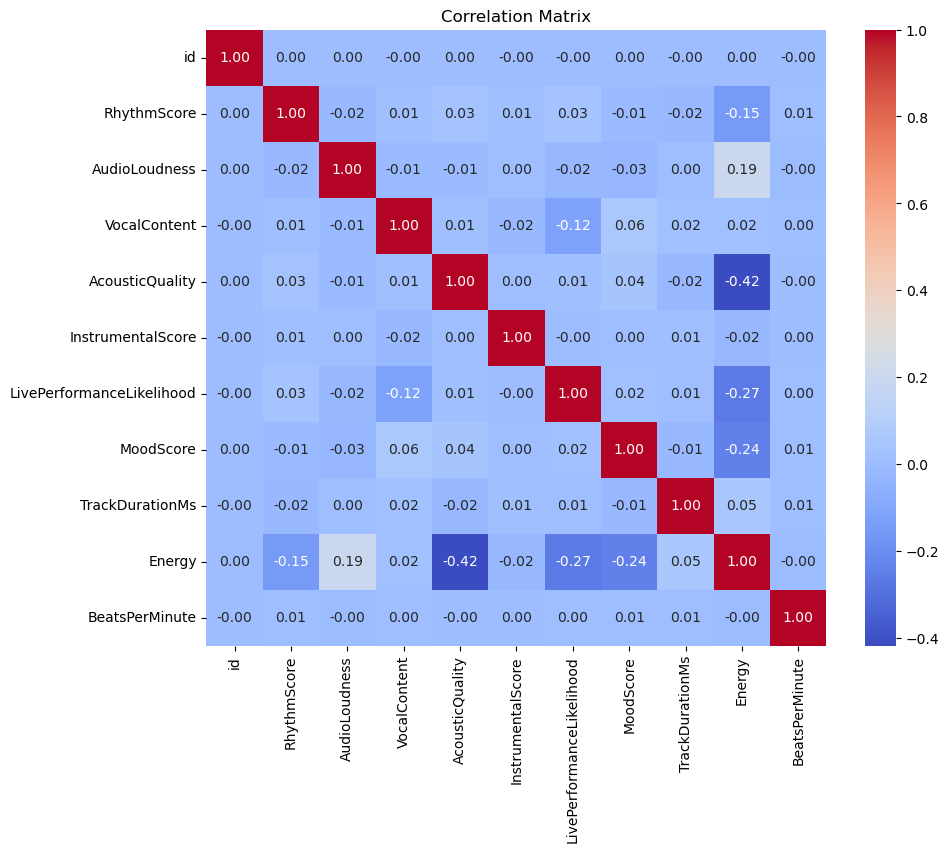

In [140]:
plt.figure(figsize=(10, 8))
sns.heatmap(train.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

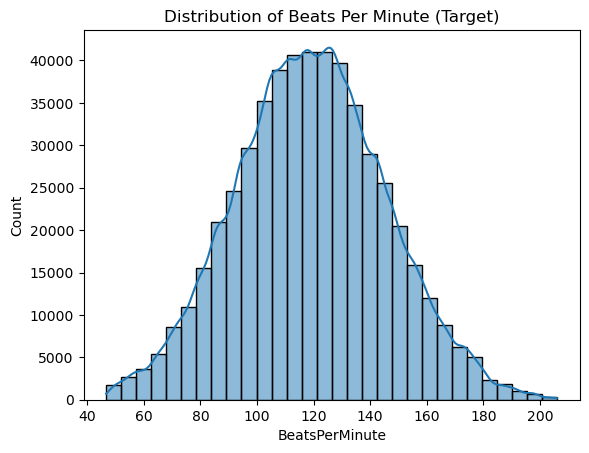

In [104]:
# Quick distribution
sns.histplot(train["BeatsPerMinute"], kde=True, bins=30)
plt.title("Distribution of Beats Per Minute (Target)")
plt.show()

# **Data Preprocessing**

In [105]:
X = train.drop(columns=['id', 'BeatsPerMinute'])

y = train['BeatsPerMinute']

X_test_final = test.drop(columns=['id'])

In [106]:
num_columns = X.columns.tolist()

In [107]:
numeric_pipe = Pipeline([
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_columns)
    ],
    remainder="drop"
)




In [108]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)


# Helper Functions

In [109]:
def evaluate_model(model, X_train, y_train, X_valid, y_valid, name):
    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_valid)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    mae = mean_absolute_error(y_valid, y_pred)
    r2 = r2_score(y_valid, y_pred)

    print(f"\n--- {name} ---")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE : {mae:.3f}")
    print(f"R²  : {r2:.3f}")

    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

# **Model Building**

# Decision Tree

In [110]:
dt_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

In [111]:
dt_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [112]:
y_pred = dt_pipe.predict(X_valid)

In [113]:
#Metrics
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)


print(f"RMSE: {rmse:.3f}")
print(f"MAE : {mae:.3f}")
print(f"R²  : {r2:.3f}")

RMSE: 38.391
MAE : 30.718
R²  : -1.107


# XGBoost

In [114]:
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42))
])

# LightGBM

In [115]:
lgbm_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(random_state=42))
])

# Linear Regression

In [116]:
lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [117]:
lr_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [118]:
y_pred = lr_pipe.predict(X_valid)

In [119]:
#Metrics
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)


print(f"RMSE: {rmse:.3f}")
print(f"MAE : {mae:.3f}")
print(f"R²  : {r2:.3f}")

RMSE: 26.444
MAE : 21.184
R²  : 0.000


# Random Forest

In [152]:
rf_pipe = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42, max_depth= 3))
])

In [ ]:
rf_pipe.fit(X_train, y_train)

# **Model Evaluation**

In [153]:
# ============================
# 📊 Collect Results
# ============================
models = [
    ("Linear Regression", lr_pipe),
    ("Decision Tree", dt_pipe),
    ("Random Forest", rf_pipe),
    ("XGBoost", xgb_pipe),
    ("LightGBM", lgbm_pipe)
]

results = []
for name, model in models:
    res = evaluate_model(model, X_train, y_train, X_valid, y_valid, name)
    results.append(res)

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)



--- Linear Regression ---
RMSE: 26.444
MAE : 21.184
R²  : 0.000

--- Decision Tree ---
RMSE: 38.391
MAE : 30.718
R²  : -1.107

--- Random Forest ---
RMSE: 26.440
MAE : 21.181
R²  : 0.000

--- XGBoost ---
RMSE: 26.553
MAE : 21.274
R²  : -0.008

--- LightGBM ---
RMSE: 26.443
MAE : 21.186
R²  : 0.000

Model Comparison:
               Model       RMSE        MAE        R2
0  Linear Regression  26.443880  21.184139  0.000095
1      Decision Tree  38.390873  30.717659 -1.107484
2      Random Forest  26.439826  21.180824  0.000402
3            XGBoost  26.553388  21.273981 -0.008204
4           LightGBM  26.443291  21.185833  0.000139


d:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


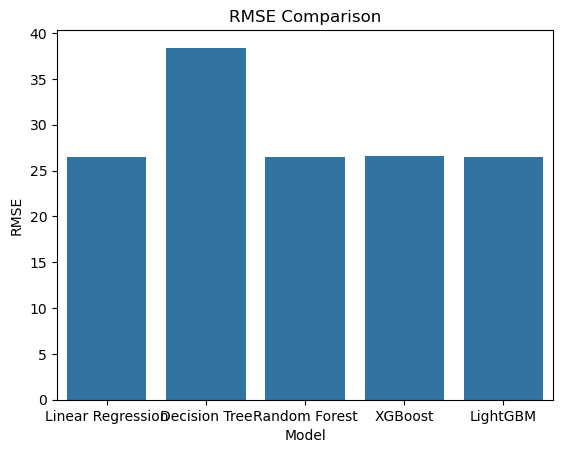

In [ ]:
# checking which one RMSE is low

sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("RMSE Comparison")
plt.show()

**Among All the models we use Random Forest**

In [122]:
best_model = lr_pipe

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

In [123]:
cv_scores

array([-26.44762004, -26.55421212, -26.41426609, -26.43916913,
       -26.47617652])

In [124]:
best_model.fit(X, y)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [125]:
preds = best_model.predict(X_test_final)

# **Final Model Training & Prediction**

In [156]:
best_model = rf_pipe

best_model.fit(X, y)

#cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# **Predict on Test Data**

In [157]:
preds = best_model.predict(X_test_final)

# **Final Submission**

In [126]:
#submission = pd.DataFrame({
#    "id": test["id"],
#    "BeatsPerMinute": preds
#})
#
#submission.to_csv("submission.csv", index=False)
#print("✅ submission.csv saved!")

In [158]:
submission = pd.DataFrame({
    "id": test["id"],
    "BeatsPerMinute": preds
})

submission.to_csv("submission1.csv", index=False)
print("✅ submission.csv saved!")

✅ submission.csv saved!


# Checking Using HyperParameter Tuning

In [127]:
best_model = xgb_pipe

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

In [128]:
cv_scores

array([-26.54593454, -26.64508799, -26.53388028, -26.5334644 ,
       -26.57171297])

In [129]:
best_model = lgbm_pipe 

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

In [130]:
cv_scores

array([-26.44878922, -26.55343302, -26.414129  , -26.43851617,
       -26.47486031])

In [131]:
from sklearn.linear_model import Ridge, Lasso

ridge_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0, random_state=42))
])

lasso_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.005, random_state=42))
])


In [132]:
best_model = ridge_pipe

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

In [133]:
cv_scores

array([-26.44762004, -26.55421212, -26.41426609, -26.43916913,
       -26.47617652])

In [134]:
best_model = lasso_pipe

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)

In [135]:
cv_scores

array([-26.44765651, -26.55420204, -26.41427681, -26.43919093,
       -26.47607292])

In [136]:
from sklearn.model_selection import GridSearchCV

param_grid = {"model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(ridge_pipe, param_grid, cv=5,
                    scoring="neg_root_mean_squared_error", n_jobs=-1)
grid.fit(X, y)

print("Best alpha:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)


Best alpha: {'model__alpha': 100}
Best CV RMSE: 26.466288629464685


In [137]:
from sklearn.linear_model import Lasso

lasso_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(random_state=42, max_iter=10000))
])

param_grid = {"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1]}
grid = GridSearchCV(lasso_pipe, param_grid, cv=5,
                    scoring="neg_root_mean_squared_error", n_jobs=-1)
grid.fit(X, y)

print("Best alpha:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)


Best alpha: {'model__alpha': 0.01}
Best CV RMSE: 26.466280069546826


In [138]:
from sklearn.linear_model import ElasticNet

enet_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ElasticNet(random_state=42, max_iter=10000))
])

param_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1],
    "model__l1_ratio": [0.1, 0.5, 0.9]  # 0=ridge, 1=lasso
}
grid = GridSearchCV(enet_pipe, param_grid, cv=5,
                    scoring="neg_root_mean_squared_error", n_jobs=-1)
grid.fit(X, y)

print("Best params:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)


Best params: {'model__alpha': 0.1, 'model__l1_ratio': 0.1}
Best CV RMSE: 26.466271342358688


In [139]:
from sklearn.preprocessing import PolynomialFeatures

poly_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", Ridge(alpha=1.0))
])

cv_scores = cross_val_score(poly_pipe, X, y, cv=5,
                            scoring="neg_root_mean_squared_error", n_jobs=-1)
print("Poly Ridge RMSE:", -cv_scores.mean())


Poly Ridge RMSE: 26.46646567457796


In [145]:
rf_pipe.fit(X_train, y_train)

,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [147]:
y_pred = lr_pipe.predict(X_valid)

#Metrics
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
mae = mean_absolute_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)


print(f"RMSE: {rmse:.3f}")
print(f"MAE : {mae:.3f}")
print(f"R²  : {r2:.3f}")

RMSE: 26.443
MAE : 21.184
R²  : 0.000


In [150]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [3, 5, 10]
    #'model__min_samples_split': [2, 5, 10],
    #'model__min_samples_leaf': [1, 2, 4]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    n_jobs=-1,               # Use all CPU cores
    scoring='neg_mean_squared_error',  # For regression
    verbose=2
)
